In [1]:
# packages and modules

from Bio import SeqIO, AlignIO
from pymsaviz import MsaViz
import subprocess
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# read in fasta file, check sequences

file_path = "FinalProject1_SA.fa"

for record in SeqIO.parse(file_path, "fasta"):
    print(f"ID: {record.id}")
    print(f"Description: {record.description}")
    print(f"Sequence length: {len(record.seq)}")
    print(f"Sequence: {record.seq}\n")

ID: ref|NR_117835.1
Description: ref|NR_117835.1
Sequence length: 540
Sequence: AAGGGCGTGTAGGCGGGACCGTAAGTCTGGTTTTAAAGACTGAGGCTCAACCTCAGGAG-TGGACTGGATACTGCGATCCTTGACCTCTGGG-GAGGCAACCGG-AATTCCTGGTGTAGCGGTGGAATGCGTAGATA-CCAGGAGGAACACCAATGG-CGAAGGCAGGTTGCTGGACAGAAGGTGACGCTGAGGCGCGAAAGTGT-GGGGAGCAAA-CCGGATTAGATACCCGGGTAGTCCACACCCTAAACGATGTACGTTGGCTCATGGCAGGATGCTGTCATGGGCGAAGCTAACGCGATAAACGTACCGCCTGGGAAGTACGGCCGCAAGGTTGAAACTCAAAGGAATTGACGGGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGAAGCAACGCGAAGAACCTTACCAGGTCTTGACATGCACAGAACTTCTCAGAAATGAGAGGGTGCCC-TTCGGGGAACTGTGACACAGGTGCTGCATGGCTGT--CGTC-AGCT-CGTGTCGTGAGATGTTGGGTTAA-GTCCCGC

ID: ref|NR_044497.1
Description: ref|NR_044497.1
Sequence length: 540
Sequence: AAGGGCGTGTAGGCGGGAACTTAAGTCTGGTTTTAAAGACCGGGGCTCAACCTCGGGGA-TGGACTGGATACTGGGTTTCTTGATCTCTGGA-GAGGTAACCGG-AATTCCTGGTGTAGCGGTGGAATGCGTAGATA-CCAGGAGGAACACCAATGG-CGAAGGCAGGTTACTGGACAGAAGATGACGCTGAGGCGCGAAAGTGT-GGGGAGCGAA-CCGGATTAGATACCCGGGTAGTCCACACCCTAAACGATGCACGTTGGCTTAACGCAGGATGCTGTGTTGGGCGAAGCTAAC

In [3]:
# create alignment file

alignments = AlignIO.parse(file_path, "fasta-pearson")
for alignment in alignments:
    print(alignment)
    print()

Alignment with 3 rows and 540 columns
AAGGGCGTGTAGGCGGGACCGTAAGTCTGGTTTTAAAGACTGAG...CGC ref|NR_117835.1
AAGGGCGTGTAGGCGGGAACTTAAGTCTGGTTTTAAAGACCGGG...CGC ref|NR_044497.1
AAGGGCGTGTAGGCGGACGTGTAAGTCTGGTTTTAAAGACCGGG...CGC gb|KU042972.2



In [4]:
# use MUSCLE to perform alignment

# cmd = "muscle -align FinalProject1_SA.fa -output alignment.txt"
# results = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, text=True)

# code commented out after .txt file is created so it doesn't run again

In [5]:
# read in alignment .txt file

align = AlignIO.read("alignment.txt", "fasta")
print(align)

Alignment with 3 rows and 527 columns
AAGGGCGTGTAGGCGGACGTGTAAGTCTGGTTTTAAAGACCGGG...CGC gb|KU042972.2
AAGGGCGTGTAGGCGGGACCGTAAGTCTGGTTTTAAAGACTGAG...CGC ref|NR_117835.1
AAGGGCGTGTAGGCGGGAACTTAAGTCTGGTTTTAAAGACCGGG...CGC ref|NR_044497.1


In [6]:
# create MSA chart, save as png

mv = MsaViz(align, wrap_length=80, show_count=True)
mv.savefig("msa.png")

In [7]:
# create nodes and labels for flowchart

nodes = {'m1_16': 'AAGGGCGTGTAGGCGG',
        'a17': 'A', 'b17': 'G', 
        'a18': 'C', 'b18': 'A',
        'a19': 'G', 'b19': 'C', 'c19': 'A',
        'a20': 'T', 'b20': 'C',
        'a21': 'G', 'b21': 'T',
        'm22_40': 'TAAGTCTGGTTTTAAAGAC',
        'a41': 'C', 'b41': 'T',
        'm42': 'G',
        'a43': 'G', 'b43': 'A',
        'm44_54': 'GGCTCAACCTC',
        'a55': 'G', 'b55': 'A',
        'm56_57': 'GG',
        'a58': 'G', 'b58': 'A',
        'a59': 'G', 'b59': 'A',
        'm60_73': 'TGGACTGGATACTG',
        'a74': 'C', 'b74': 'G',
        'a75': 'A', 'b75': 'G',
        'a76': 'G', 'b76': 'A', 'c76': 'T',
        'a77': 'G', 'b77': 'T',
        'a78': 'T', 'b78': 'C',
        'm79_83': 'CTTGA',
        'a84': 'T', 'b84': 'C',
        'm85_90': 'CTCTGG',
        'a91': 'A', 'b91': 'G',
        'm92_95': 'GAGG',
        'a96': 'T', 'b96': 'C',
        'm97_100': 'AACC'}

In [8]:
# create edges for flowchart

edges = [('m1_16', 'a17'), ('m1_16', 'b17'),
        ('a17', 'a18'), ('a17', 'b18'), ('b17', 'a18'), ('b17', 'b18'),
        ('a18', 'a19'), ('a18', 'b19'), ('a18', 'c19'), ('b18', 'a19'), ('b18', 'b19'), ('b18', 'c19'),
        ('a19', 'a20'), ('a19', 'b20'), ('b19', 'a20'), ('b19', 'b20'), ('c19', 'a20'), ('c19', 'b20'),
        ('a20', 'a21'), ('a20', 'b21'), ('b20', 'a21'), ('b20', 'b21'),
        ('a21', 'm22_40'), ('b21', 'm22_40'),
        ('m22_40', 'a41'), ('m22_40', 'b41'),
        ('a41', 'm42'), ('b41', 'm42'),
        ('m42', 'a43'), ('m42', 'b43'),
        ('a43', 'm44_54'), ('b43', 'm44_54'),
        ('m44_54', 'a55'), ('m44_54', 'b55'),
        ('a55', 'm56_57'), ('b55', 'm56_57'),
        ('m56_57', 'a58'), ('m56_57', 'b58'),
        ('a58', 'a59'), ('a58', 'b59'), ('b58', 'a59'), ('b58', 'b59'),
        ('a59', 'm60_73'), ('b59', 'm60_73'),
        ('m60_73', 'a74'), ('m60_73', 'b74'),
        ('a74', 'a75'), ('a74', 'b75'), ('b74', 'a75'), ('b74', 'b75'),
        ('a75', 'a76'), ('a75', 'b76'), ('a75', 'c76'), ('b75', 'a76'), ('b75', 'b76'), ('b75', 'c76'),
        ('a76', 'a77'), ('a76', 'b77'), ('b76', 'a77'), ('b76', 'b77'), ('c76', 'a77'), ('c76', 'b77'),
        ('a77', 'a78'), ('a77', 'b78'),('b77', 'a78'), ('b77', 'b78'),
        ('a78', 'm79_83'), ('b78', 'm79_83'),
        ('m79_83', 'a84'), ('m79_83', 'b84'),
        ('a84', 'm85_90'), ('b84', 'm85_90'),
        ('m85_90', 'a91'), ('m85_90', 'b91'),
        ('a91', 'm92_95'), ('b91', 'm92_95'),
        ('m92_95', 'a96'), ('m92_95', 'b96'),
        ('a96', 'm97_100'), ('b96', 'm97_100')]

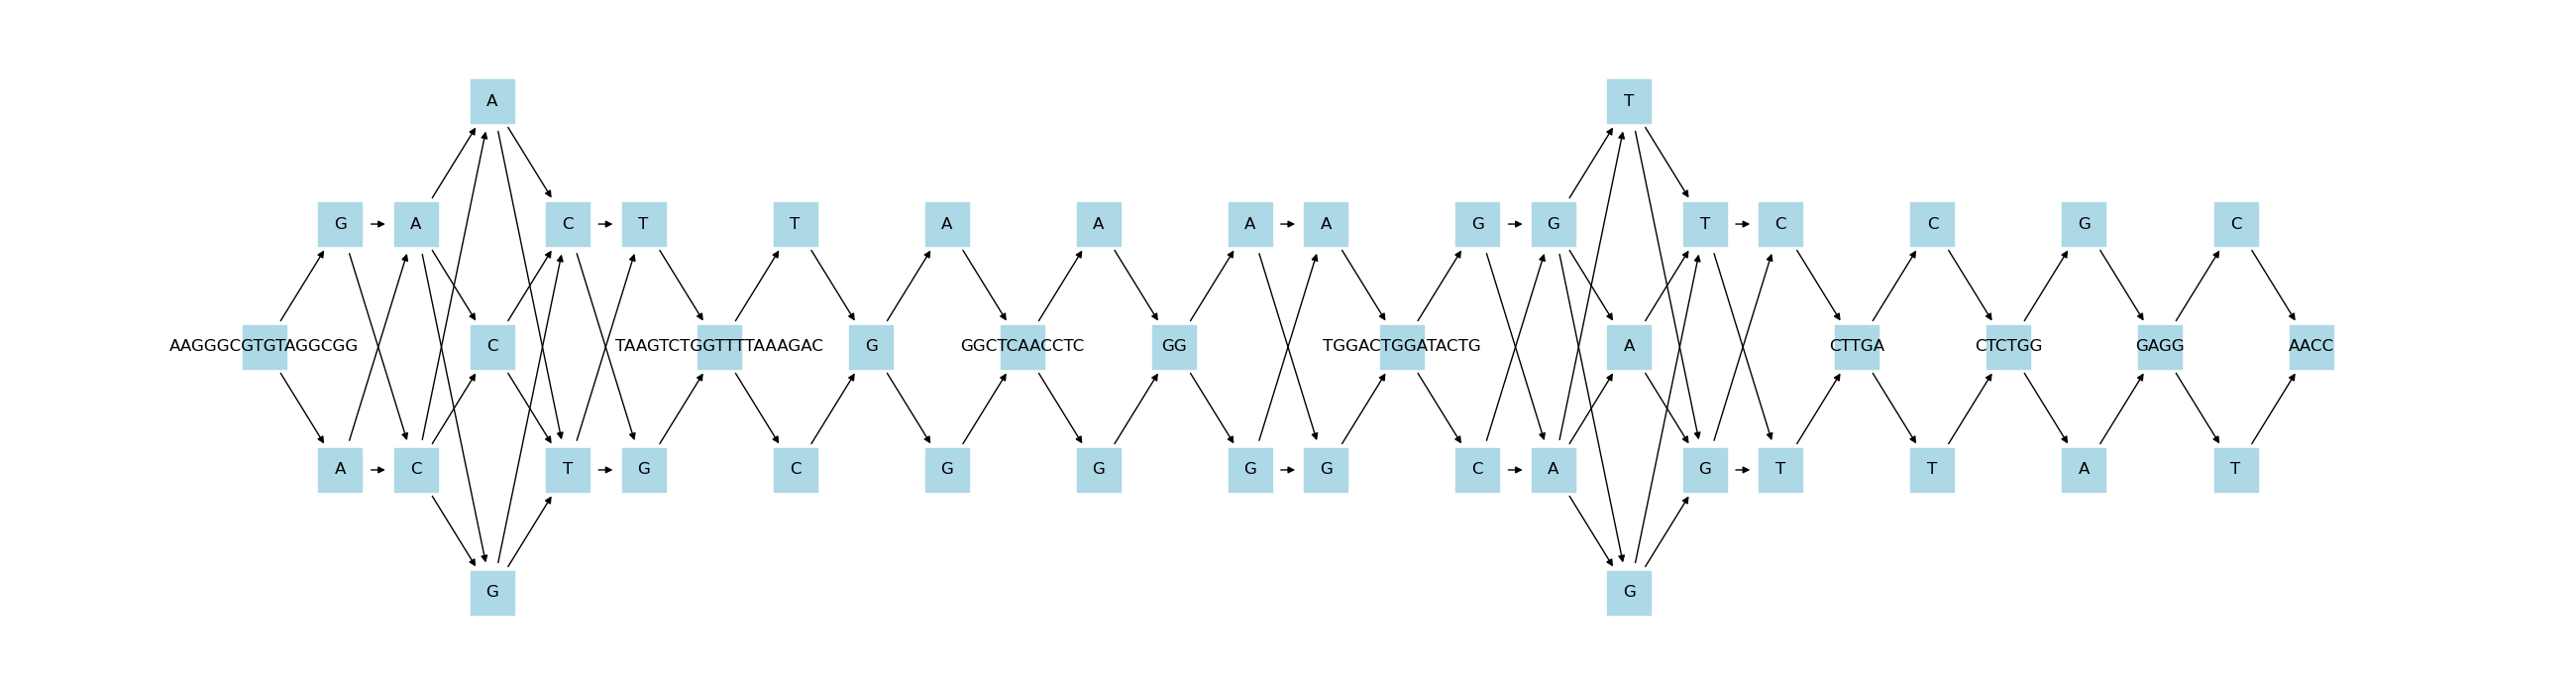

In [9]:
# create flowchart and edit style

G = nx.DiGraph()

G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize=(25, 6))

nx.draw(G, node_shape = 's',
        with_labels=True, labels = nodes,
        pos = nx.bfs_layout(G, start = 'm1_16'),
        font_size = 12, node_size = 1000,
       node_color = 'lightblue')